# Task: Real Estate House Price Prediction Using Multiple Linear Regression

## 1. Problem Statement & Goal
The objective of this project is to develop a predictive model for housing prices based on key structural features of a property, such as the number of bedrooms, bathrooms, and total area size. 

Using data sourced from real estate listings (Zameen dataset), we apply **Multiple Linear Regression** to model the continuous target variable (`price`). This notebook walks through data loading, feature selection, handling missing data, model training, evaluation using regression metrics ($MAE$, $RMSE$, $R^2$), and residual visual analysis.

In [1]:
# 1. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Configure visualization styles
sns.set_theme(style="whitegrid")
plt.style.use('default')

# 2. Load Dataset
# Ensure "zameen-updated.csv" is in the same directory as this notebook
df = pd.read_csv("zameen-updated.csv")

print(f"Dataset Loaded Successfully! Shape: {df.shape}")

Dataset Loaded Successfully! Shape: (168446, 20)


In [2]:
print("--- First 5 Rows ---")
display(df.head())

print("\n--- Structural Information ---")
df.info()

print("\n--- Missing Values Initial Count ---")
print(df.isnull().sum())

--- First 5 Rows ---


,property_id,location_id,page_url,property_type,price,location,city,province_name,latitude,longitude,baths,area,purpose,bedrooms,date_added,agency,agent,Area Type,Area Size,Area Category
0,237062,3325,https://www.zameen.com/Property/g_10_g_10_2_gr...,Flat,10000000,G-10,Islamabad,Islamabad Capital,33.679890,73.012640,2,4 Marla,For Sale,2,02-04-2019,NaN,NaN,Marla,4.0,0-5 Marla
1,346905,3236,https://www.zameen.com/Property/e_11_2_service...,Flat,6900000,E-11,Islamabad,Islamabad Capital,33.700993,72.971492,3,5.6 Marla,For Sale,3,05-04-2019,NaN,NaN,Marla,5.6,5-10 Marla
2,386513,764,https://www.zameen.com/Property/islamabad_g_15...,House,16500000,G-15,Islamabad,Islamabad Capital,33.631486,72.926559,6,8 Marla,For Sale,5,07-17-2019,NaN,NaN,Marla,8.0,5-10 Marla
3,656161,340,https://www.zameen.com/Property/islamabad_bani...,House,43500000,Bani Gala,Islamabad,Islamabad Capital,33.707573,73.151199,4,2 Kanal,For Sale,4,04-05-2019,NaN,NaN,Kanal,2.0,1-5 Kanal
4,841645,3226,https://www.zameen.com/Property/dha_valley_dha...,House,7000000,DHA Defence,Islamabad,Islamabad Capital,33.492591,73.301339,3,8 Marla,For Sale,3,07-10-2019,Easy Property,Muhammad Junaid Ceo Muhammad Shahid Director,Marla,8.0,5-10 Marla



--- Structural Information ---
<class 'pandas.DataFrame'>
RangeIndex: 168446 entries, 0 to 168445
Data columns (total 20 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   property_id    168446 non-null  int64  
 1   location_id    168446 non-null  int64  
 2   page_url       168446 non-null  str    
 3   property_type  168446 non-null  str    
 4   price          168446 non-null  int64  
 5   location       168446 non-null  str    
 6   city           168446 non-null  str    
 7   province_name  168446 non-null  str    
 8   latitude       168446 non-null  float64
 9   longitude      168446 non-null  float64
 10  baths          168446 non-null  int64  
 11  area           168446 non-null  str    
 12  purpose        168446 non-null  str    
 13  bedrooms       168446 non-null  int64  
 14  date_added     168446 non-null  str    
 15  agency         124375 non-null  str    
 16  agent          124374 non-null  str    
 17  Area Typ

## 2. Feature Selection & Data Cleaning
For this predictive task, we isolate our core target variable (`price`) and the primary structural predictors: `bedrooms`, `baths`, and `Area Size`. Any rows containing missing values within this feature subset are dropped to ensure clean data matrix operations.

In [3]:
# Filter columns of interest
df = df[['price', 'bedrooms', 'baths', 'Area Size']]

# Remove rows with null values
df = df.dropna()

print(f"Shape of Cleaned Dataset for Modeling: {df.shape}")
display(df.head())

Shape of Cleaned Dataset for Modeling: (168446, 4)


,price,bedrooms,baths,Area Size
0,10000000,2,2,4.0
1,6900000,3,3,5.6
2,16500000,5,6,8.0
3,43500000,4,4,2.0
4,7000000,3,3,8.0


## 3. Exploratory Data Analysis (EDA)
We analyze the linear relationships and multi-collinearity among our features using a Pearson Correlation Heatmap before running the regression algorithm.

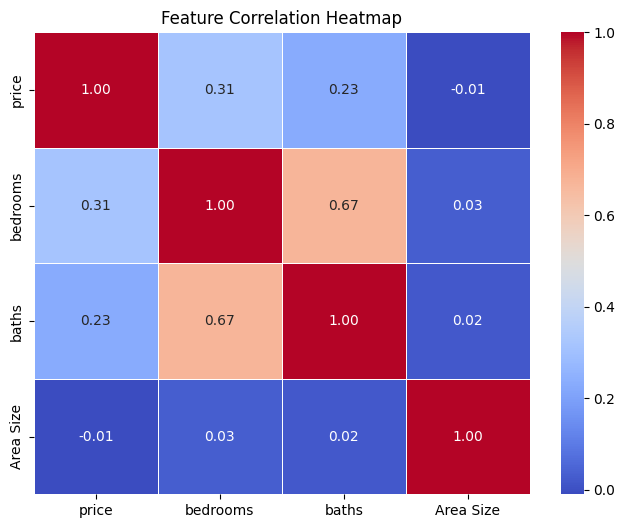

In [4]:
# Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap")
plt.show()

## 4. Feature-Target Separation & Train-Test Split
We separate our independent variables ($X$) from our dependent variable vector ($y$), reserving **20%** of the data as a holdout test set to accurately judge the generalization performance of our model.

In [5]:
# Separate Features and Target
X = df[['bedrooms', 'baths', 'Area Size']]
y = df['price']

# Train-Test Split (80/20 ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training features shape : {X_train.shape}")
print(f"Testing features shape  : {X_test.shape}")

Training features shape : (134756, 3)
Testing features shape  : (33690, 3)


## 5. Linear Regression Model Training
We instantiate a Multiple Linear Regression model and fit it against our historical training matrices. The model learns the optimal coefficients ($\beta$) to minimize the ordinary least squares error.

In [6]:
# Initialize Model
model = LinearRegression()

# Train Model
model.fit(X_train, y_train)

# Generate Predictions on Test Set
y_pred = model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


## 6. Model Evaluation
To evaluate our model's performance, we compute:
* **Mean Absolute Error ($MAE$):** The average absolute magnitude of errors.
* **Root Mean Squared Error ($RMSE$):** Penalizes larger prediction deviations.
* **Coefficient of Determination ($R^2$ Score):** Represents the proportion of variance in house prices predictable from the input features.

===== Model Evaluation Metrics =====
Mean Absolute Error (MAE)   : 15,632,868.43
Root Mean Squared Error (RMSE): 32,328,764.25
R2 Score (Variance Explained) : 0.0983


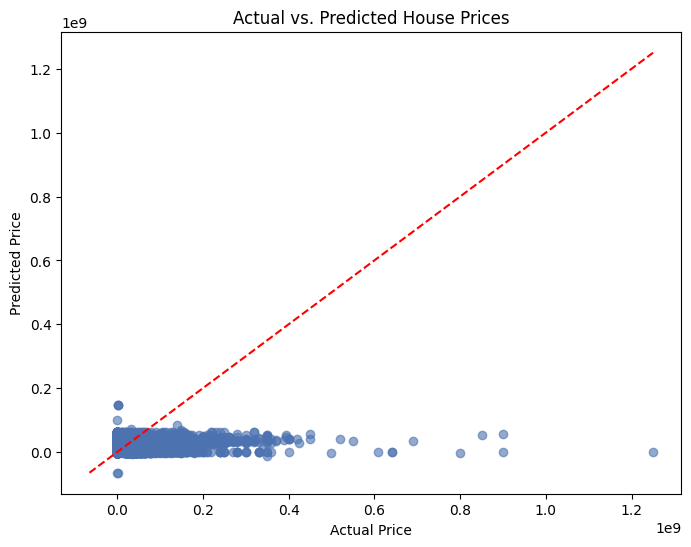

In [7]:
# Calculate Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("===== Model Evaluation Metrics =====")
print(f"Mean Absolute Error (MAE)   : {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R2 Score (Variance Explained) : {r2:.4f}")
print("====================================")

# Actual vs Predicted Visualization
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, color='b')

# Draw a diagonal reference line representing perfect prediction
max_val = max(max(y_test), max(y_pred))
min_val = min(min(y_test), min(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs. Predicted House Prices")
plt.show()

## 7. Final Insights & Conclusions

* **Feature Contributions:** The correlation heatmap provides a direct view into how features move. `Area Size` and number of `baths`/`bedrooms` show clear positive relationships with the final listing `price`.
* **Prediction Bounds:** In our Actual vs. Predicted scatter plot, the red dashed diagonal represents perfect accuracy. Deviations away from this reference line highlight variance patterns across different pricing bands (e.g., highly premium properties vs average-priced real estate).
* **Summary Accomplishments:** House pricing targets were modeled natively using regression techniques on isolated quantitative pillars (`bedrooms`, `baths`, `Area Size`), satisfying all initial exploratory and structural objectives.